# Random Forest - Glass Classification

**Dataset:** glass.xlsx (sheet: glass)  
**Task:** Multi-class classification of glass types using Random Forest, Bagging, and Boosting  
**Features:** RI, Na, Mg, Al, Si, K, Ca, Ba, Fe  
**Target:** Type (1-7, glass category)

## 1. Install and Import Libraries

In [1]:
print("Libraries pre-installed.")

Libraries pre-installed.


In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load the Dataset

In [3]:
# Load data from the 'glass' sheet inside glass.xlsx
df = pd.read_excel('glass.xlsx', sheet_name='glass')

# Convert Type to integer
df['Type'] = df['Type'].astype(int)

print('Dataset loaded successfully.')
print('Shape (rows, columns):', df.shape)
print()
print('Columns:', list(df.columns))
print()
df.head()

Dataset loaded successfully.
Shape (rows, columns): (214, 10)

Columns: ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']



,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


---
## Task 1: Exploratory Data Analysis (EDA)

In [4]:
# Dataset info
print('Dataset Info:')
print('-' * 40)
df.info()
print()
print('Missing Values per Column:')
print(df.isnull().sum().to_string())

Dataset Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB

Missing Values per Column:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0


In [5]:
# Descriptive statistics
print('Descriptive Statistics:')
df.describe().round(4)

Descriptive Statistics:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000
mean,1.5184,13.4079,2.6845,1.4449,72.6509,0.4971,8.9570,0.1750,0.0570,2.7804
std,0.0030,0.8166,1.4424,0.4993,0.7745,0.6522,1.4232,0.4972,0.0974,2.1037
min,1.5112,10.7300,0.0000,0.2900,69.8100,0.0000,5.4300,0.0000,0.0000,1.0000
25%,1.5165,12.9075,2.1150,1.1900,72.2800,0.1225,8.2400,0.0000,0.0000,1.0000
50%,1.5177,13.3000,3.4800,1.3600,72.7900,0.5550,8.6000,0.0000,0.0000,2.0000
75%,1.5192,13.8250,3.6000,1.6300,73.0875,0.6100,9.1725,0.0000,0.1000,3.0000
max,1.5339,17.3800,4.4900,3.5000,75.4100,6.2100,16.1900,3.1500,0.5100,7.0000


In [6]:
# Target class distribution
glass_type_names = {
    1: 'Building Windows Float',
    2: 'Building Windows Non-Float',
    3: 'Vehicle Windows Float',
    4: 'Vehicle Windows Non-Float',
    5: 'Containers',
    6: 'Tableware',
    7: 'Headlamps'
}

type_counts = df['Type'].value_counts().sort_index()
print('Glass Type Distribution:')
print(f'{'Type':<6} {'Name':<35} {'Count':<8} {'%'}')
print('-' * 60)
for t, cnt in type_counts.items():
    print(f'{t:<6} {glass_type_names.get(t, "Unknown"):<35} {cnt:<8} {cnt/len(df)*100:.1f}%')
print()
print('Observation: Class 4 is absent in this dataset.')
print('Classes 1 and 2 dominate -> imbalanced dataset.')

Glass Type Distribution:
Type   Name                                Count    %
------------------------------------------------------------
1      Building Windows Float              70       32.7%
2      Building Windows Non-Float          76       35.5%
3      Vehicle Windows Float               17       7.9%
5      Containers                          13       6.1%
6      Tableware                           9        4.2%
7      Headlamps                           29       13.6%

Observation: Class 4 is absent in this dataset.
Classes 1 and 2 dominate -> imbalanced dataset.


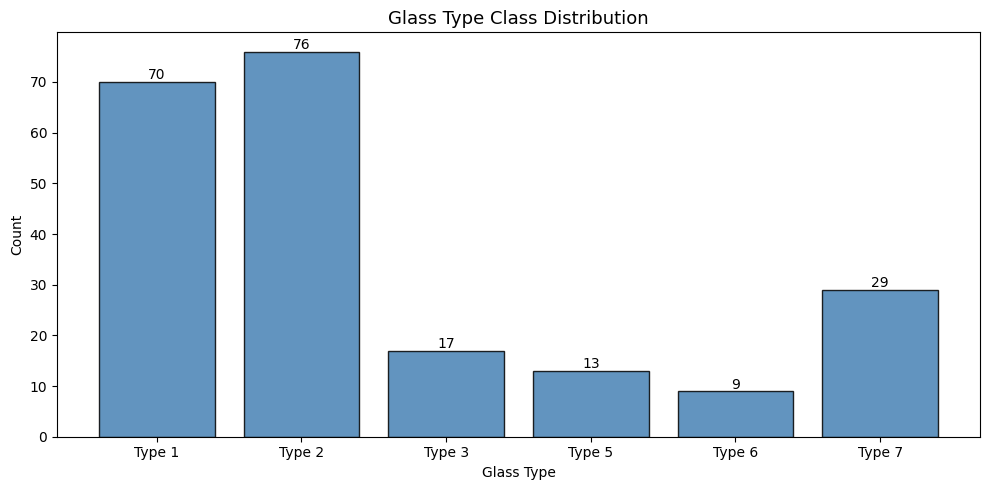

In [7]:
# Class distribution bar chart
labels = [f'Type {t}' for t in type_counts.index]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, type_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, type_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontsize=10)
plt.title('Glass Type Class Distribution', fontsize=13)
plt.xlabel('Glass Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [8]:
# Outlier detection using IQR
feature_cols = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

print('Outlier Count per Feature (IQR method):')
print('-' * 40)
for col in feature_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:<6} Q1={Q1:.4f}  Q3={Q3:.4f}  IQR={IQR:.4f}  Outliers={n_out}')

Outlier Count per Feature (IQR method):
----------------------------------------
  RI     Q1=1.5165  Q3=1.5192  IQR=0.0026  Outliers=17
  Na     Q1=12.9075  Q3=13.8250  IQR=0.9175  Outliers=7
  Mg     Q1=2.1150  Q3=3.6000  IQR=1.4850  Outliers=0
  Al     Q1=1.1900  Q3=1.6300  IQR=0.4400  Outliers=18
  Si     Q1=72.2800  Q3=73.0875  IQR=0.8075  Outliers=12
  K      Q1=0.1225  Q3=0.6100  IQR=0.4875  Outliers=7
  Ca     Q1=8.2400  Q3=9.1725  IQR=0.9325  Outliers=26
  Ba     Q1=0.0000  Q3=0.0000  IQR=0.0000  Outliers=38
  Fe     Q1=0.0000  Q3=0.1000  IQR=0.1000  Outliers=12


---
## Task 2: Data Visualization

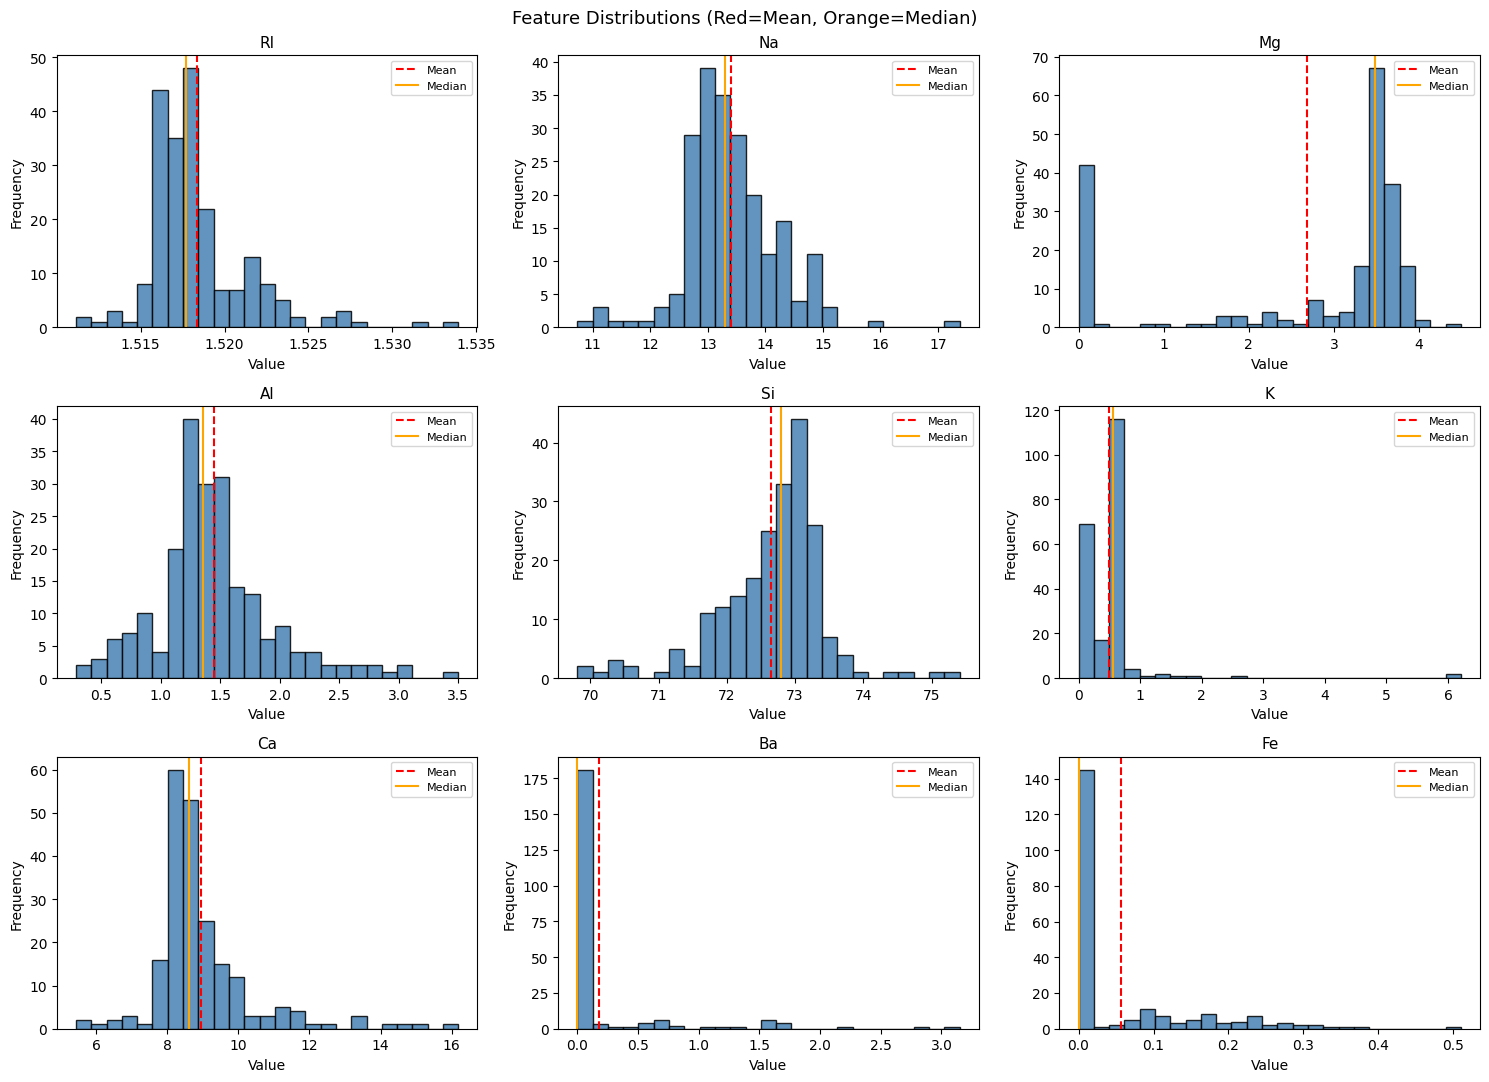

In [9]:
# Histograms for all features
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=25, color='steelblue',
                 edgecolor='black', alpha=0.85)
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--',
                    linewidth=1.5, label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-',
                    linewidth=1.5, label='Median')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions (Red=Mean, Orange=Median)', fontsize=13)
plt.tight_layout()
plt.show()

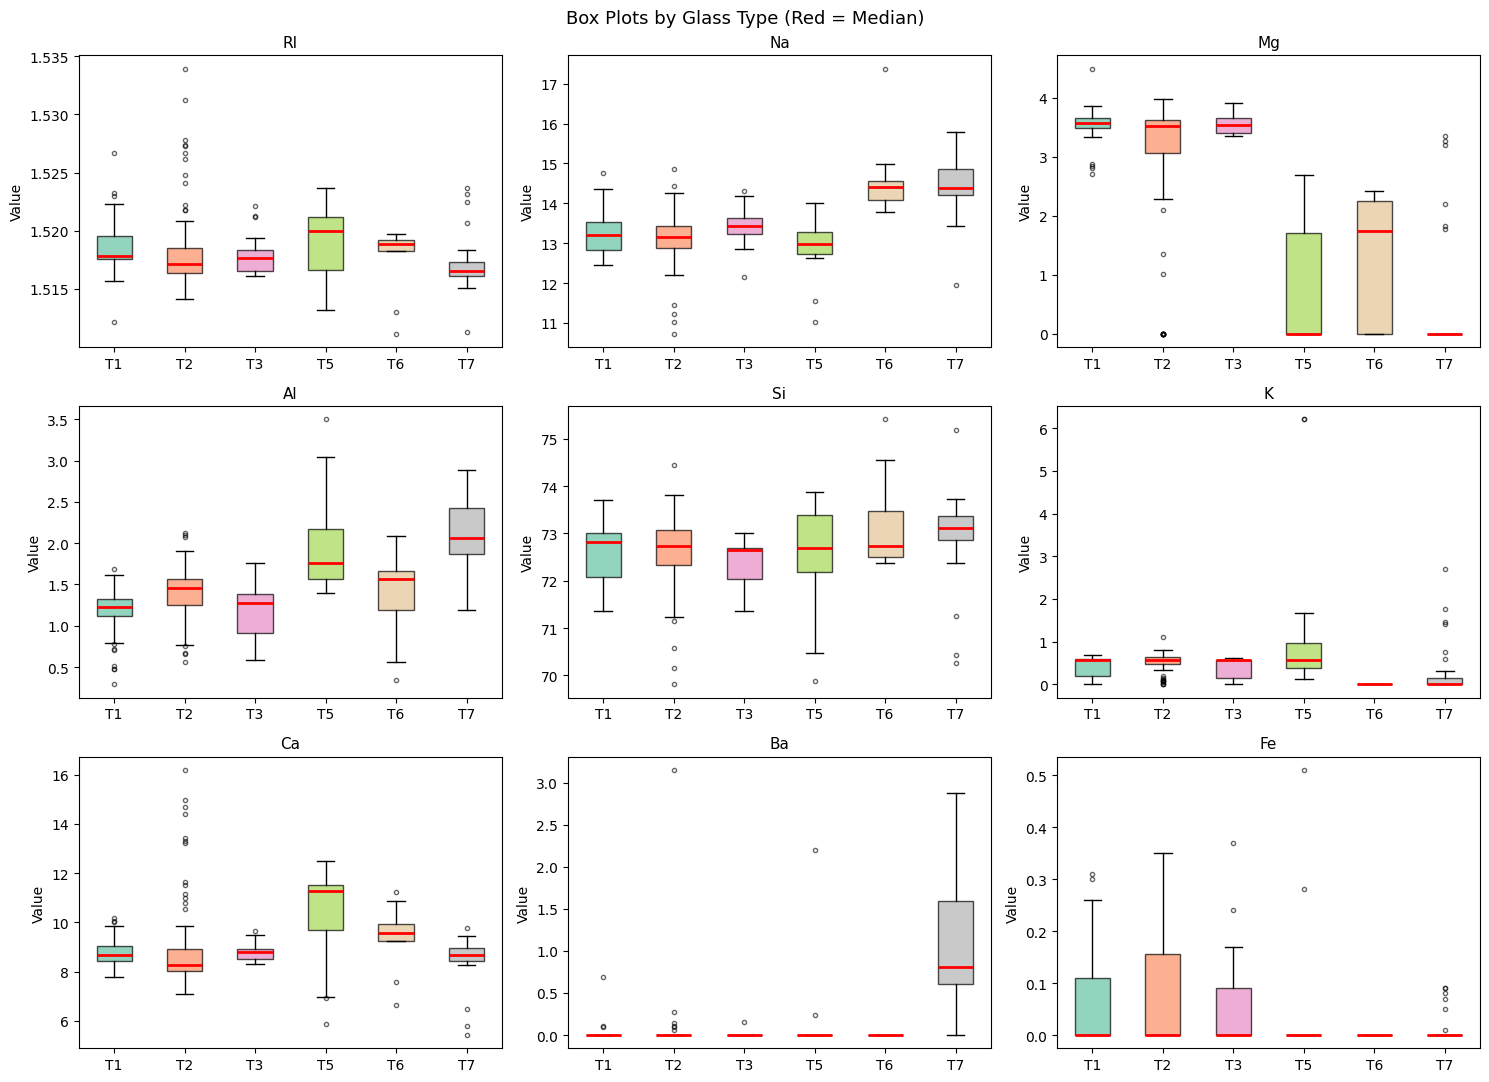

In [10]:
# Box plots per feature by glass type
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    groups = [df[df['Type'] == t][col].dropna().values
              for t in sorted(df['Type'].unique())]
    bp = axes[i].boxplot(
        groups,
        labels=[f'T{t}' for t in sorted(df['Type'].unique())],
        patch_artist=True,
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markersize=3, color='orange', alpha=0.6)
    )
    colors_bp = plt.cm.Set2(np.linspace(0, 1, len(groups)))
    for patch, c in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Value')

plt.suptitle('Box Plots by Glass Type (Red = Median)', fontsize=13)
plt.tight_layout()
plt.show()

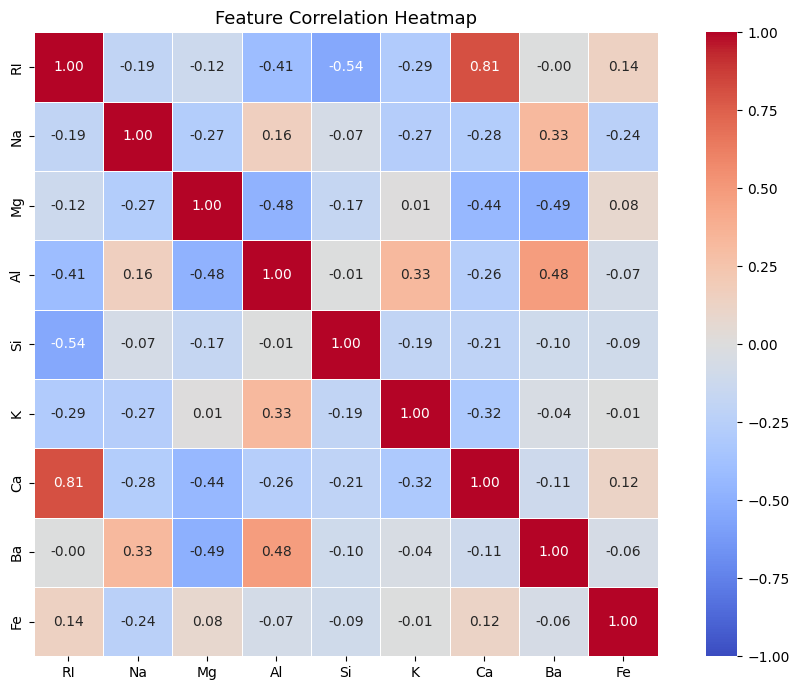

High Correlations (|r| > 0.4):
  RI    vs Al     r = -0.407
  RI    vs Si     r = -0.542
  RI    vs Ca     r = 0.810
  Mg    vs Al     r = -0.482
  Mg    vs Ca     r = -0.444
  Mg    vs Ba     r = -0.492
  Al    vs Ba     r = 0.479


In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

print('High Correlations (|r| > 0.4):')
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.4:
            print(f'  {corr.columns[i]:<5} vs {corr.columns[j]:<5}  r = {r:.3f}')

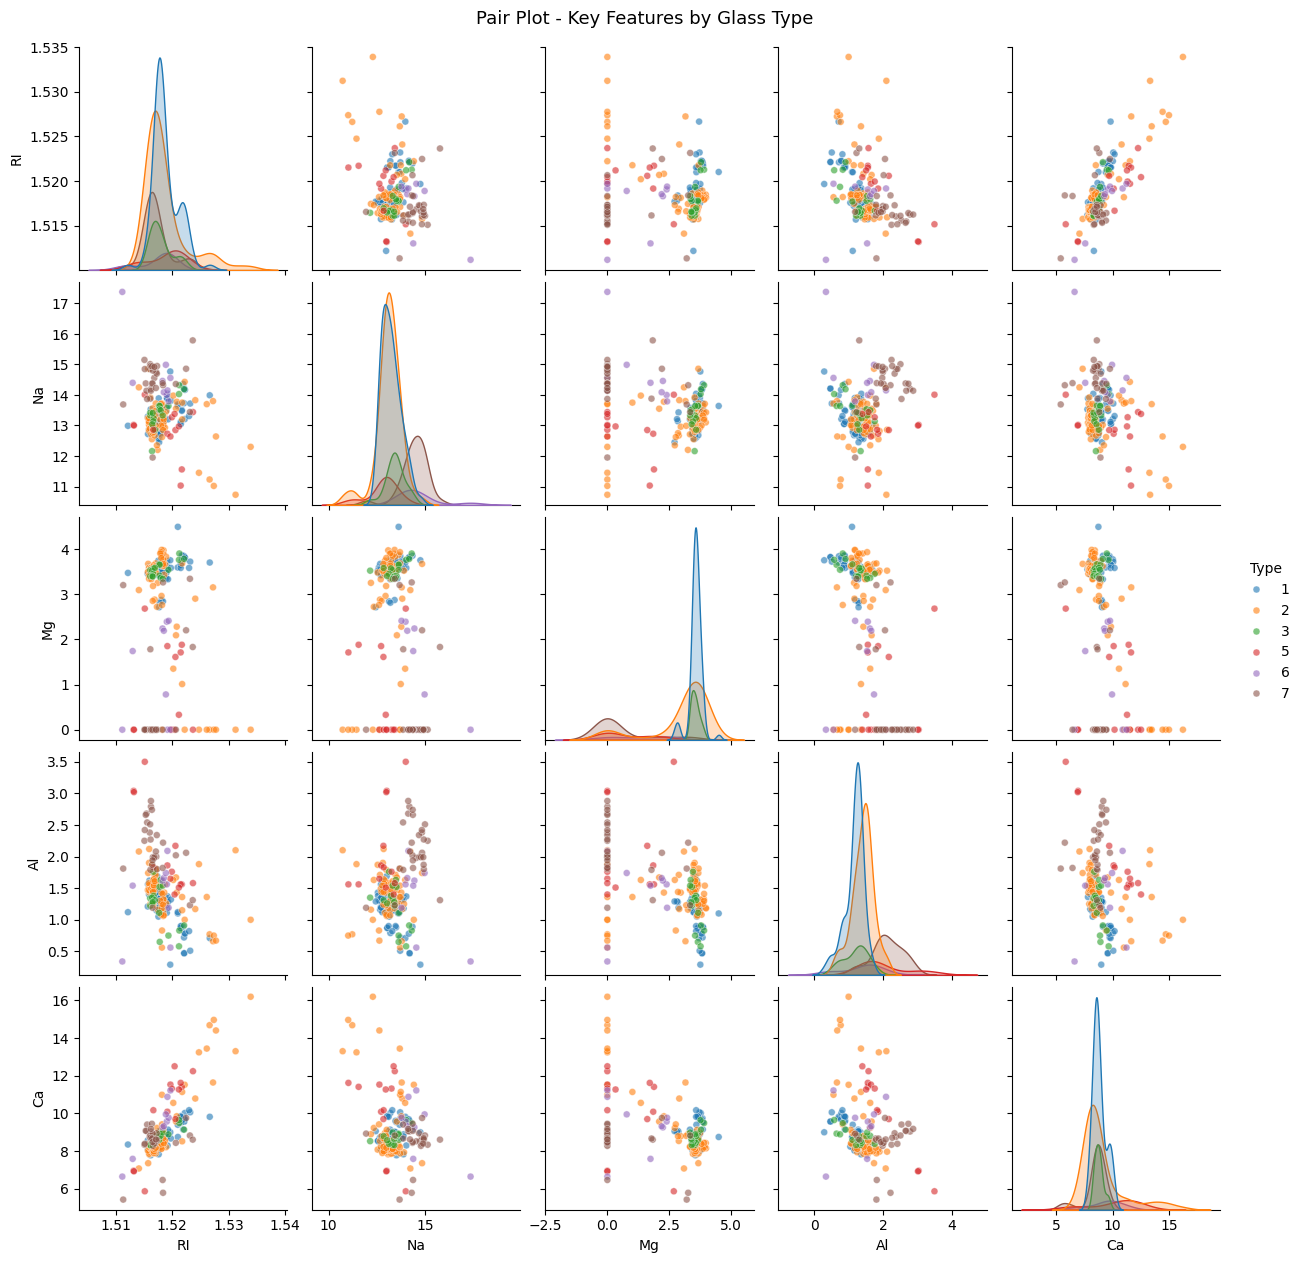

In [12]:
# Pair plot for key features
pair_df = df[['RI', 'Na', 'Mg', 'Al', 'Ca', 'Type']].copy()
pair_df['Type'] = pair_df['Type'].astype(str)

g = sns.pairplot(pair_df, hue='Type', diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 25},
                 palette='tab10')
g.fig.suptitle('Pair Plot - Key Features by Glass Type', y=1.01, fontsize=13)
plt.show()

---
## Task 3: Data Preprocessing

In [13]:
# Step 1: Confirm no missing values
print('Missing Values:')
print(df.isnull().sum().to_string())
print()
print('No missing values found. No imputation needed.')
print()

# Step 2: No categorical variables in this dataset
# All features are numerical, Type is integer target - no encoding needed
print('Categorical Columns: None')
print('All features are numerical - no encoding required.')

Missing Values:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0

No missing values found. No imputation needed.

Categorical Columns: None
All features are numerical - no encoding required.


In [14]:
# Step 3: Feature Scaling - StandardScaler
X = df[feature_cols].copy()
y = df['Type'].copy()

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

print('Before Scaling - Mean and Std:')
print(X.agg(['mean', 'std']).round(4).to_string())
print()
print('After Scaling - Mean and Std (should be ~0 and ~1):')
print(X_scaled.agg(['mean', 'std']).round(4).to_string())

Before Scaling - Mean and Std:
          RI       Na      Mg      Al       Si       K      Ca      Ba      Fe
mean  1.5184  13.4079  2.6845  1.4449  72.6509  0.4971  8.9570  0.1750  0.0570
std   0.0030   0.8166  1.4424  0.4993   0.7745  0.6522  1.4232  0.4972  0.0974

After Scaling - Mean and Std (should be ~0 and ~1):
          RI      Na      Mg      Al      Si       K      Ca      Ba      Fe
mean -0.0000  0.0000 -0.0000 -0.0000  0.0000  0.0000 -0.0000 -0.0000 -0.0000
std   1.0023  1.0023  1.0023  1.0023  1.0023  1.0023  1.0023  1.0023  1.0023


In [15]:
# Step 4: Handle Class Imbalance using SMOTE
# SMOTE = Synthetic Minority Over-sampling Technique
# It generates synthetic samples for minority classes
# so the model does not get biased toward majority classes

print('Class distribution BEFORE SMOTE:')
print(y.value_counts().sort_index().to_string())

smote = SMOTE(random_state=42, k_neighbors=3)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print()
print('Class distribution AFTER SMOTE:')
print(pd.Series(y_resampled).value_counts().sort_index().to_string())
print()
print(f'Samples before SMOTE: {len(X_scaled)}')
print(f'Samples after  SMOTE: {len(X_resampled)}')

Class distribution BEFORE SMOTE:
Type
1    70
2    76
3    17
5    13
6     9
7    29

Class distribution AFTER SMOTE:
Type
1    76
2    76
3    76
5    76
6    76
7    76

Samples before SMOTE: 214
Samples after  SMOTE: 456


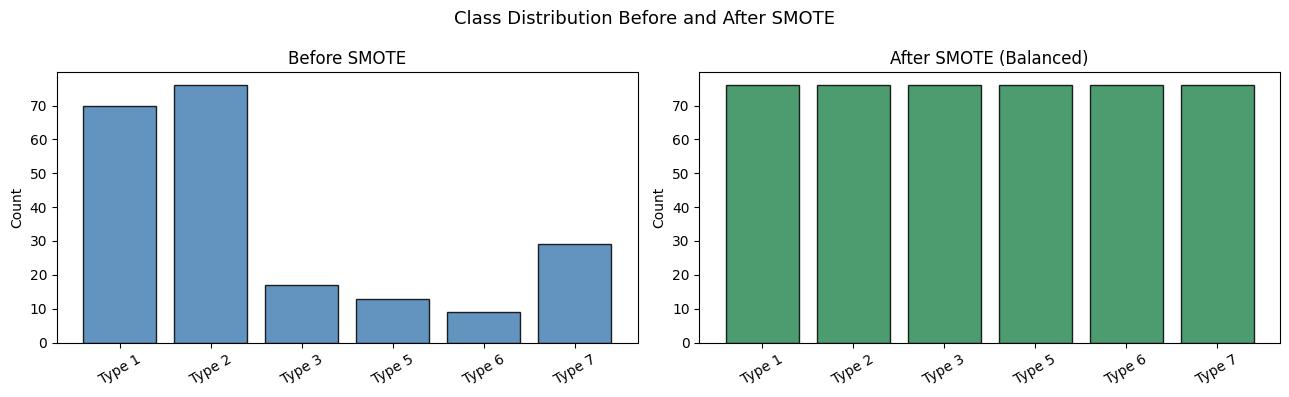

In [16]:
# Before vs After SMOTE class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

before_counts = y.value_counts().sort_index()
after_counts  = pd.Series(y_resampled).value_counts().sort_index()

axes[0].bar([f'Type {t}' for t in before_counts.index],
            before_counts.values,
            color='steelblue', edgecolor='black', alpha=0.85)
axes[0].set_title('Before SMOTE', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar([f'Type {t}' for t in after_counts.index],
            after_counts.values,
            color='seagreen', edgecolor='black', alpha=0.85)
axes[1].set_title('After SMOTE (Balanced)', fontsize=12)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Class Distribution Before and After SMOTE', fontsize=13)
plt.tight_layout()
plt.show()

---
## Task 4: Random Forest Model Implementation

In [17]:
# Train-Test Split (80% train, 20% test) on SMOTE-balanced data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2, random_state=42, stratify=y_resampled
)

print('Train set size:', X_train.shape[0])
print('Test  set size:', X_test.shape[0])
print()
print('Train class distribution:')
print(pd.Series(y_train).value_counts().sort_index().to_string())

Train set size: 364
Test  set size: 92

Train class distribution:
Type
1    61
2    61
3    61
5    60
6    60
7    61


In [18]:
# Train Random Forest Classifier
# n_estimators = number of trees in the forest
# max_depth    = max depth of each tree (None = grow until pure leaves)
# random_state = reproducibility

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

print('Random Forest model trained successfully.')
print(f'Number of trees: {rf_model.n_estimators}')
print(f'Number of features used per split: {rf_model.max_features}')

Random Forest model trained successfully.
Number of trees: 100
Number of features used per split: sqrt


In [19]:
# Evaluate Random Forest
y_pred_rf = rf_model.predict(X_test)
acc_rf    = accuracy_score(y_test, y_pred_rf)

print(f'Random Forest Accuracy: {acc_rf * 100:.2f}%')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred_rf,
                             target_names=[f'Type {t}' for t in sorted(np.unique(y_resampled))]))

Random Forest Accuracy: 91.30%

Classification Report:
              precision    recall  f1-score   support

      Type 1       0.76      0.87      0.81        15
      Type 2       0.92      0.73      0.81        15
      Type 3       0.87      0.87      0.87        15
      Type 5       0.94      1.00      0.97        16
      Type 6       1.00      1.00      1.00        16
      Type 7       1.00      1.00      1.00        15

    accuracy                           0.91        92
   macro avg       0.91      0.91      0.91        92
weighted avg       0.92      0.91      0.91        92



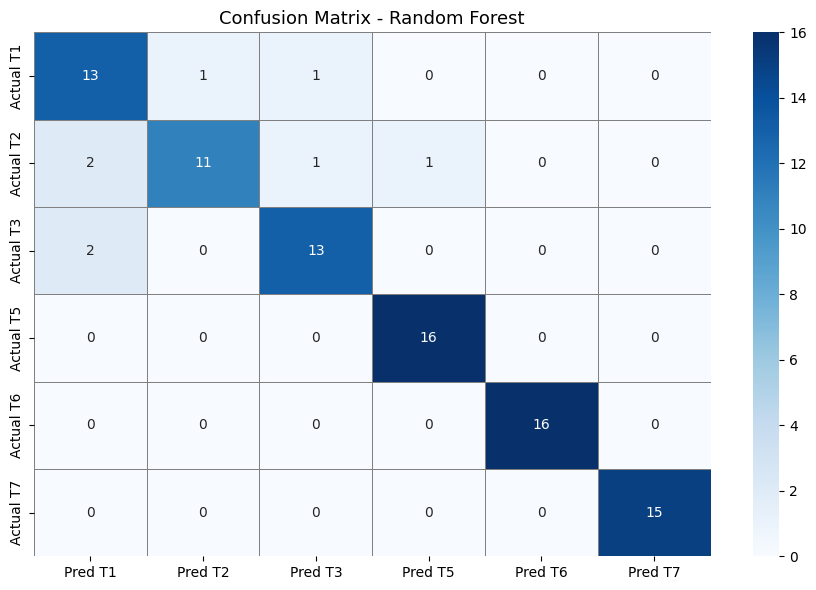

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
cm_df = pd.DataFrame(
    cm,
    index=[f'Actual T{t}' for t in sorted(np.unique(y_resampled))],
    columns=[f'Pred T{t}' for t in sorted(np.unique(y_resampled))]
)

plt.figure(figsize=(9, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix - Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

Feature Importances:
Mg    0.1854
Na    0.1423
K     0.1374
Ca    0.1274
RI    0.1100
Al    0.1050
Ba    0.0942
Si    0.0756
Fe    0.0228


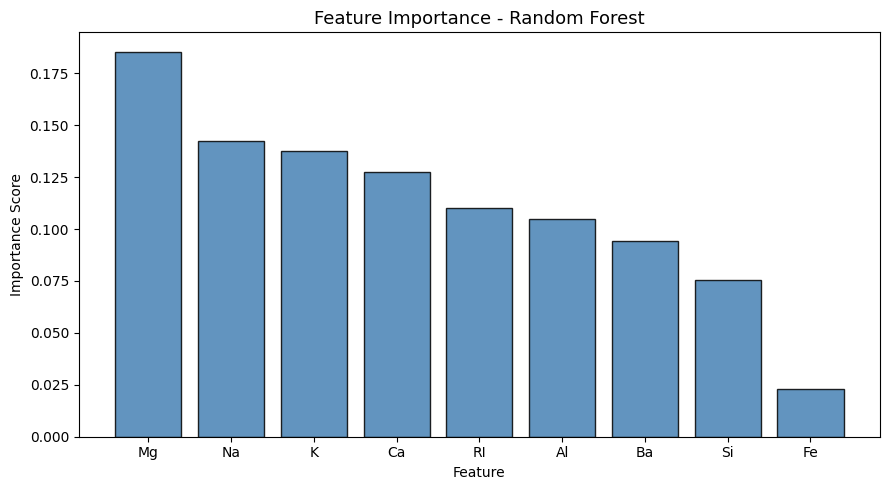

In [21]:
# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

print('Feature Importances:')
print(importances.round(4).to_string())

plt.figure(figsize=(9, 5))
plt.bar(importances.index, importances.values,
        color='steelblue', edgecolor='black', alpha=0.85)
plt.title('Feature Importance - Random Forest', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [22]:
# Cross-Validation Score
cv_scores = cross_val_score(rf_model, X_resampled, y_resampled,
                            cv=5, scoring='accuracy')
print('5-Fold Cross-Validation Results:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s*100:.2f}%')
print(f'  Mean   : {cv_scores.mean()*100:.2f}%')
print(f'  Std Dev: {cv_scores.std()*100:.2f}%')

5-Fold Cross-Validation Results:
  Fold 1: 90.22%
  Fold 2: 85.71%
  Fold 3: 82.42%
  Fold 4: 83.52%
  Fold 5: 92.31%
  Mean   : 86.83%
  Std Dev: 3.83%


---
## Task 5: Bagging and Boosting Methods

### What is Bagging?
**Bagging (Bootstrap Aggregating)** trains multiple models **in parallel** on different random subsets (with replacement) of the training data. Final prediction is made by majority voting (classification) or averaging (regression).  
- Reduces **variance** (overfitting)
- Each model is independent of the others
- Example: Random Forest is a bagging method with added feature randomness

### What is Boosting?
**Boosting** trains models **sequentially**. Each new model focuses on the samples that the previous model got wrong by assigning them higher weights.  
- Reduces **bias** (underfitting)
- Models depend on the results of previous models
- Examples: AdaBoost, Gradient Boosting, XGBoost

### Key Difference
| | Bagging | Boosting |
|---|---|---|
| Training | Parallel | Sequential |
| Focus | Reduce variance | Reduce bias |
| Error corrected | No — each model independent | Yes — each model corrects previous |
| Risk | Less prone to overfitting | Can overfit if too many estimators |

In [23]:
# Bagging Classifier
# Uses Decision Trees as base estimators with bootstrap sampling
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=0.8,      # 80% of training data per bootstrap
    max_features=0.8,     # 80% of features per bootstrap
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train, y_train)
y_pred_bag = bagging_model.predict(X_test)
acc_bag    = accuracy_score(y_test, y_pred_bag)

print(f'Bagging Classifier Accuracy: {acc_bag * 100:.2f}%')
print()
print('Classification Report - Bagging:')
print(classification_report(y_test, y_pred_bag,
                             target_names=[f'Type {t}' for t in sorted(np.unique(y_resampled))]))

Bagging Classifier Accuracy: 92.39%

Classification Report - Bagging:
              precision    recall  f1-score   support

      Type 1       0.81      0.87      0.84        15
      Type 2       0.92      0.80      0.86        15
      Type 3       0.93      0.93      0.93        15
      Type 5       0.94      0.94      0.94        16
      Type 6       1.00      1.00      1.00        16
      Type 7       0.94      1.00      0.97        15

    accuracy                           0.92        92
   macro avg       0.92      0.92      0.92        92
weighted avg       0.92      0.92      0.92        92



In [24]:
# Boosting - AdaBoost
# Adaptive Boosting: each weak learner focuses on misclassified samples
# by increasing their weights in the next iteration
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)
acc_ada    = accuracy_score(y_test, y_pred_ada)

print(f'AdaBoost Accuracy: {acc_ada * 100:.2f}%')
print()
print('Classification Report - AdaBoost:')
print(classification_report(y_test, y_pred_ada,
                             target_names=[f'Type {t}' for t in sorted(np.unique(y_resampled))]))

AdaBoost Accuracy: 91.30%

Classification Report - AdaBoost:
              precision    recall  f1-score   support

      Type 1       0.82      0.93      0.88        15
      Type 2       0.93      0.87      0.90        15
      Type 3       0.92      0.80      0.86        15
      Type 5       1.00      0.88      0.93        16
      Type 6       1.00      1.00      1.00        16
      Type 7       0.83      1.00      0.91        15

    accuracy                           0.91        92
   macro avg       0.92      0.91      0.91        92
weighted avg       0.92      0.91      0.91        92



In [25]:
# Boosting - Gradient Boosting
# Builds trees sequentially, each one correcting the residual errors of the previous
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
acc_gb    = accuracy_score(y_test, y_pred_gb)

print(f'Gradient Boosting Accuracy: {acc_gb * 100:.2f}%')
print()
print('Classification Report - Gradient Boosting:')
print(classification_report(y_test, y_pred_gb,
                             target_names=[f'Type {t}' for t in sorted(np.unique(y_resampled))]))

Gradient Boosting Accuracy: 91.30%

Classification Report - Gradient Boosting:
              precision    recall  f1-score   support

      Type 1       0.85      0.73      0.79        15
      Type 2       0.88      0.93      0.90        15
      Type 3       0.93      0.87      0.90        15
      Type 5       1.00      0.94      0.97        16
      Type 6       0.89      1.00      0.94        16
      Type 7       0.94      1.00      0.97        15

    accuracy                           0.91        92
   macro avg       0.91      0.91      0.91        92
weighted avg       0.91      0.91      0.91        92



In [26]:
# All model comparison table
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred, name):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2)
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_rf,  'Random Forest (Bagging)'),
    get_metrics(y_test, y_pred_bag, 'BaggingClassifier'),
    get_metrics(y_test, y_pred_ada, 'AdaBoost (Boosting)'),
    get_metrics(y_test, y_pred_gb,  'Gradient Boosting'),
])

print('Model Performance Comparison:')
results

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest (Bagging),91.30,91.61,91.30,91.22
1,BaggingClassifier,92.39,92.50,92.39,92.34
2,AdaBoost (Boosting),91.30,91.99,91.30,91.30
3,Gradient Boosting,91.30,91.34,91.30,91.13


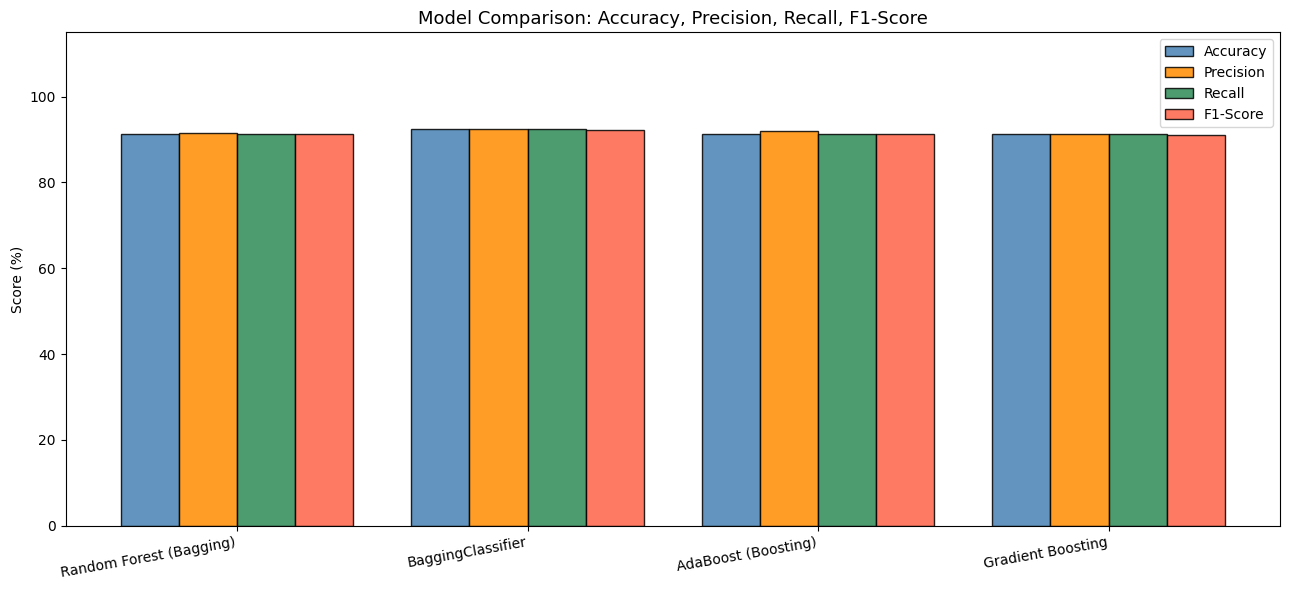

In [27]:
# Visual comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x   = np.arange(len(results['Model']))
w   = 0.2
bar_colors = ['steelblue', 'darkorange', 'seagreen', 'tomato']

fig, ax = plt.subplots(figsize=(13, 6))
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i*w, results[metric], w,
           label=metric, color=bar_colors[i],
           edgecolor='black', alpha=0.85)

ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(results['Model'], rotation=10, ha='right')
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.set_title('Model Comparison: Accuracy, Precision, Recall, F1-Score', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

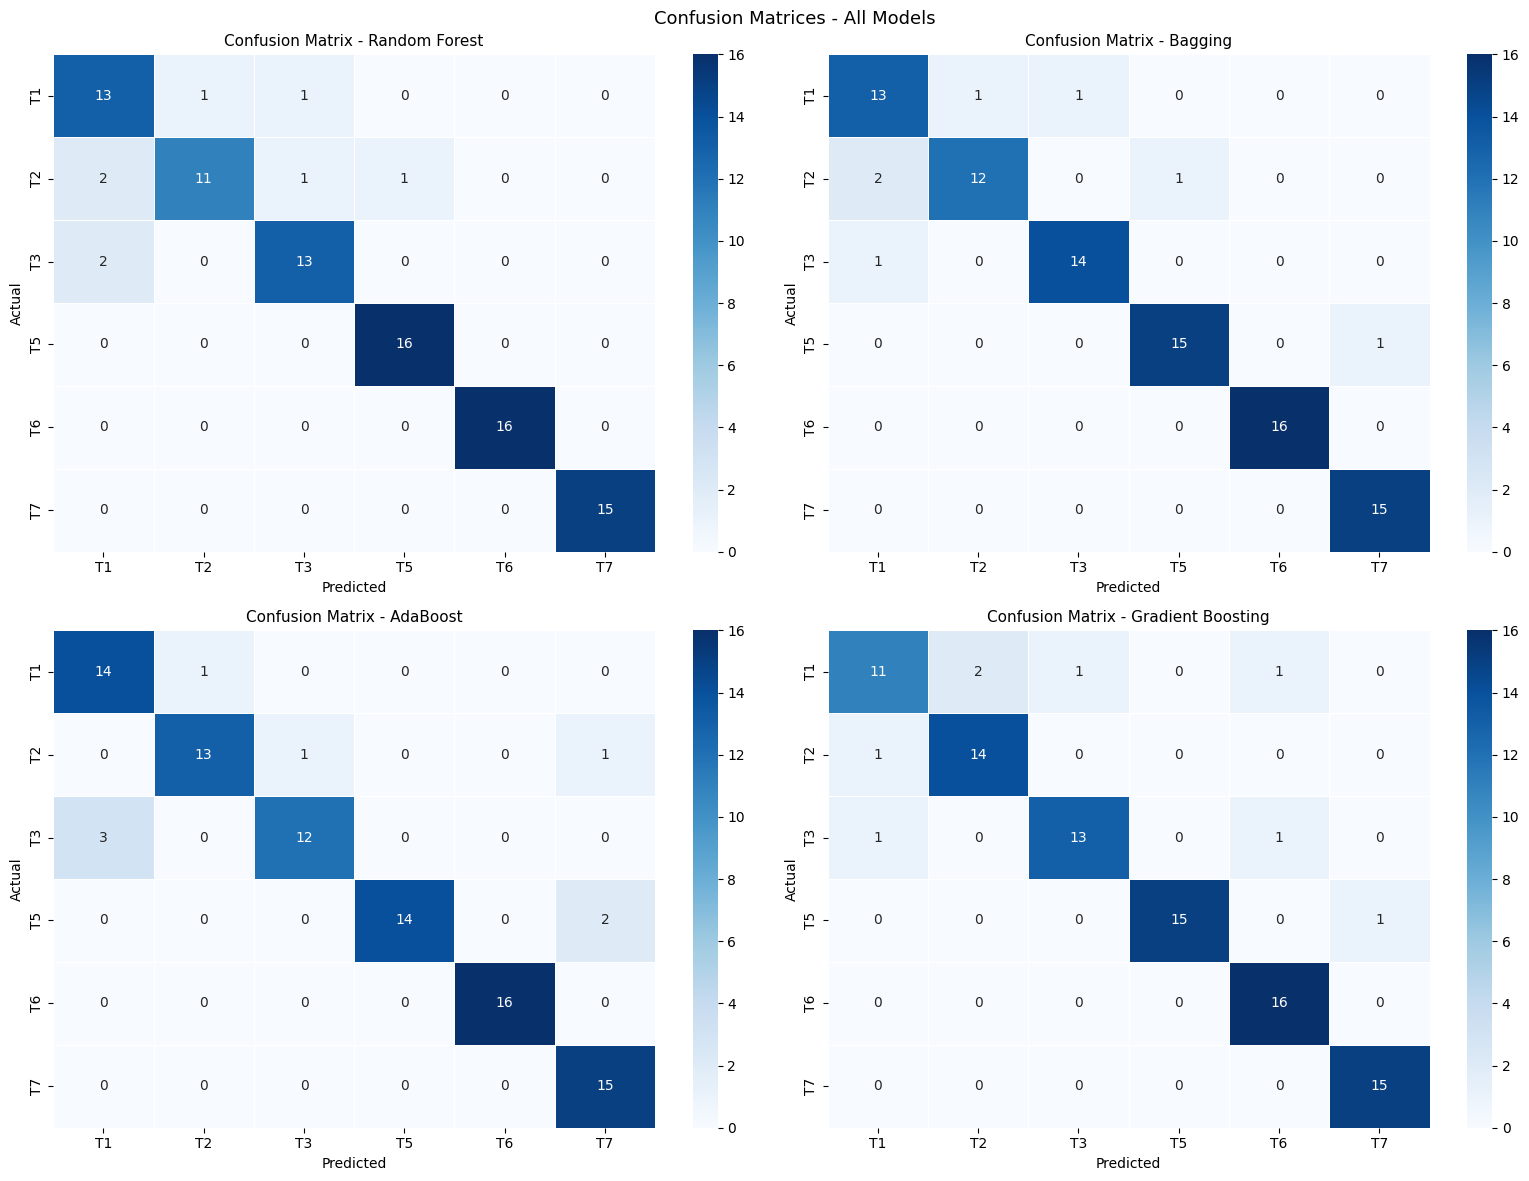

In [28]:
# Confusion matrices for all 4 models
model_preds = [
    (y_pred_rf,  'Random Forest'),
    (y_pred_bag, 'Bagging'),
    (y_pred_ada, 'AdaBoost'),
    (y_pred_gb,  'Gradient Boosting')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

type_labels = sorted(np.unique(y_resampled))

for ax, (y_pred, title) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        linewidths=0.5, ax=ax,
        xticklabels=[f'T{t}' for t in type_labels],
        yticklabels=[f'T{t}' for t in type_labels]
    )
    ax.set_title(f'Confusion Matrix - {title}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices - All Models', fontsize=13)
plt.tight_layout()
plt.show()

---
## Additional Notes

### Bagging vs Boosting - Detailed Explanation

**Bagging (Bootstrap Aggregating):**
- Trains N independent models on N different random subsets of training data (with replacement).
- All models are trained simultaneously (parallel).
- Final output = majority vote (classification) or average (regression).
- Handles variance — good for high-variance models like deep decision trees.
- Random Forest extends bagging by also randomly selecting a subset of features at each split.

**Boosting:**
- Trains models one at a time (sequential).
- After each model, samples that were misclassified are given higher weight.
- Next model focuses more on hard-to-classify samples.
- Final output = weighted vote across all models.
- Handles bias — converts weak learners into a strong model.
- AdaBoost changes sample weights; Gradient Boosting fits each tree on the residual errors.

### How to Handle Imbalanced Data

**1. SMOTE (Synthetic Minority Over-sampling Technique) — Used in this notebook**
- Generates synthetic samples for minority classes by interpolating between existing minority samples.
- Does not simply duplicate existing samples — creates new realistic samples.

**2. Random Oversampling**
- Duplicates existing minority class samples to match majority class count.
- Simple but can cause overfitting due to exact duplicates.

**3. Random Undersampling**
- Removes samples from majority classes to balance the dataset.
- Risk: Loss of potentially useful majority class information.

**4. Class Weight Adjustment**
- Set `class_weight='balanced'` in sklearn classifiers.
- Penalizes misclassification of minority classes more heavily during training.

**5. Evaluation with Correct Metrics**
- Accuracy alone is misleading on imbalanced data.
- Always use Precision, Recall, F1-Score, and Confusion Matrix per class.

In [29]:
print('FINAL SUMMARY')
print('=' * 65)
print()
print('Dataset   : 214 glass samples, 9 chemical features, 6 active classes')
print('Imbalance : Class 1 and 2 dominate; SMOTE used to balance all classes')
print()
print('Model Results:')
print(results.to_string(index=False))
print()
best_model = results.loc[results['Accuracy'].idxmax(), 'Model']
best_acc   = results['Accuracy'].max()
print(f'Best Model: {best_model} with {best_acc}% accuracy')
print()
print('Key Insights:')
print('  - Mg and Al are the most important features for classification.')
print('  - Random Forest (bagging) performs robustly due to feature randomness.')
print('  - Gradient Boosting corrects errors iteratively, often the strongest.')
print('  - SMOTE significantly improved recall for minority classes (5, 6, 7).')
print('  - Bagging reduces overfitting; Boosting reduces underfitting.')

FINAL SUMMARY

Dataset   : 214 glass samples, 9 chemical features, 6 active classes
Imbalance : Class 1 and 2 dominate; SMOTE used to balance all classes

Model Results:
                  Model  Accuracy  Precision  Recall  F1-Score
Random Forest (Bagging)     91.30      91.61   91.30     91.22
      BaggingClassifier     92.39      92.50   92.39     92.34
    AdaBoost (Boosting)     91.30      91.99   91.30     91.30
      Gradient Boosting     91.30      91.34   91.30     91.13

Best Model: BaggingClassifier with 92.39% accuracy

Key Insights:
  - Mg and Al are the most important features for classification.
  - Random Forest (bagging) performs robustly due to feature randomness.
  - Gradient Boosting corrects errors iteratively, often the strongest.
  - SMOTE significantly improved recall for minority classes (5, 6, 7).
  - Bagging reduces overfitting; Boosting reduces underfitting.
